# NYC Airbnb Room Type Classification
Dataset: New York City Airbnb Open Data (Kaggle)

Link: https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data

Goal: Predict the room_type of an Airbnb listing (Entire home/apt, Private room, or Shared room) using listing attributes such as price, location, availability, and review activity.

What this notebook covers (the full ML lifecycle):

- Problem framing & data loading
- Exploratory Data Analysis (EDA) — univariate, bivariate, skewness, outliers
- Data cleaning & feature engineering
- Train / test split
- Preprocessing with ColumnTransformer + Pipeline
- Baseline model
- Multiple candidate algorithms (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting)
- Model comparison (cross-validation)
- Hyperparameter tuning of the best model
- Final evaluation on the untouched test set
- Feature importance
- Saving the final pipeline (model artifact)
- Conclusion & next steps

## 1 Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2 Load Dataset
raw CSV dataset is directly going to load into the pandas dataframes

In [3]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

df = pd.read_csv(os.path.join(path, "AB_NYC_2019.csv"))

print("Path to dataset files:", path)

Path to dataset files: C:\Users\chowd\.cache\kagglehub\datasets\dgomonov\new-york-city-airbnb-open-data\versions\3


In [4]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [6]:
df.describe(include='all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


In [7]:
df.shape

(48895, 16)

## 3. Exploratory Data Analysis (EDA)
We explore the data in the standard order every ML engineer follows:

- Missing values
- Univariate analysis (one variable at a time — distributions, skewness)
- Bivariate analysis (relationship between features and the target)
- Correlation between numeric features
- Outlier inspection

### 3.1 Missing Values

In [8]:
missing = df.isnull().sum()
missing[missing > 0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

### 3.2 Target Variable - room_type

['Private room' 'Entire home/apt' 'Shared room']

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64


<Axes: xlabel='room_type', ylabel='count'>

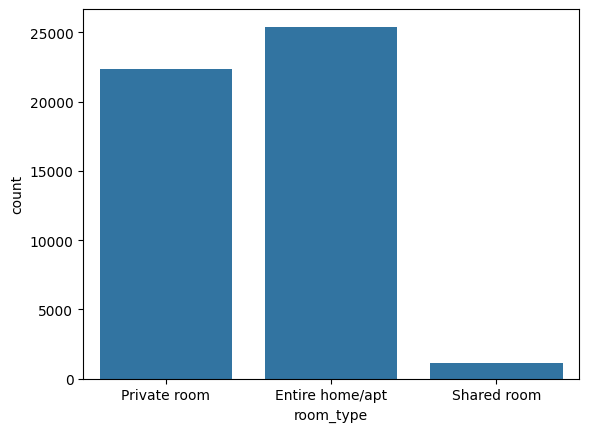

In [9]:
print(df['room_type'].unique())

print()

print(df['room_type'].value_counts())

sns.countplot(x=df['room_type'])

The classes are imbalanced -> Here the shared room is in small minority

### 3.3 Univariate Analysis - Numeric Features

In [10]:
numeric_cols = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month", "availability_365"]

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'availability_365'}>, <Axes: >]],
      dtype=object)

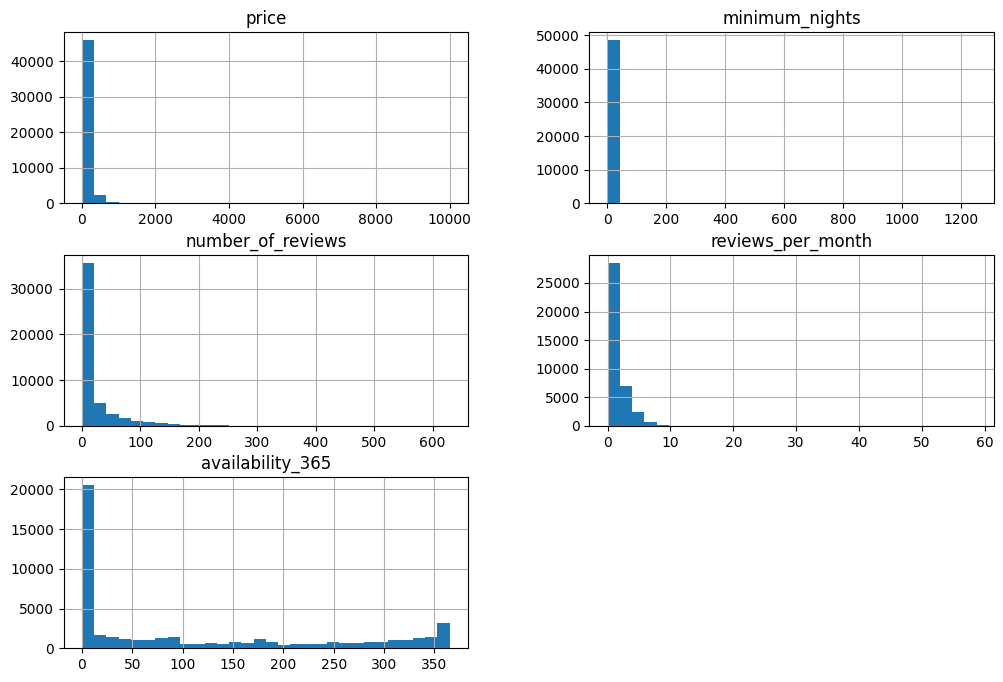

In [11]:
df[numeric_cols].hist(bins=30, figsize=(12, 8))

### 3.4 Univariate Analysis - Categorical Features

<Axes: xlabel='neighbourhood_group', ylabel='count'>

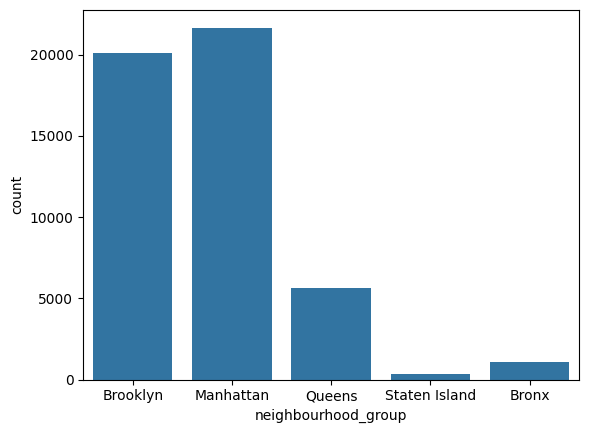

In [12]:
sns.countplot(data=df, x='neighbourhood_group')

### 3.5 Bivariate Analysis - Feature vs Target

<Axes: xlabel='room_type', ylabel='price'>

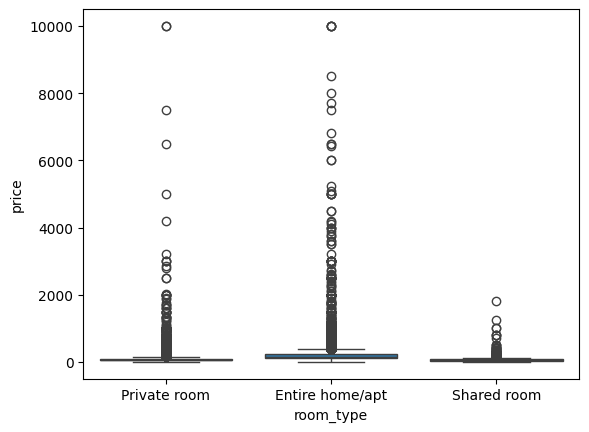

In [13]:
sns.boxplot(x='room_type', y='price', data=df)

### 3.6 Correlation between numeric features

In [14]:
corr = df[numeric_cols + ["latitude", "longitude"]].corr()

<Axes: >

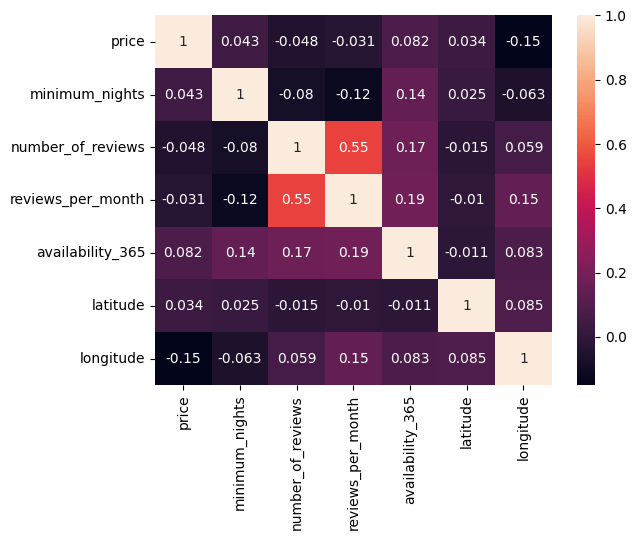

In [15]:
sns.heatmap(corr, annot=True)

### 3.7 Geographical Plot ( Bonus )

<Axes: xlabel='latitude', ylabel='longitude'>

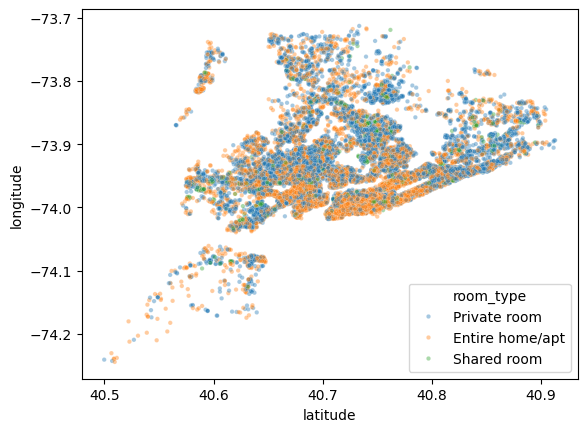

In [16]:
sns.scatterplot(x='latitude', y='longitude', data=df, hue="room_type", alpha=0.4, s=10)

## 4. Data Cleaning & Feature Engineering
Steps:

1. Drop columns that are pure identifiers or free text and carry no generalizable signal for a tabular model (id, name, host_id, host_name, last_review).
2. Fill missing reviews_per_month with 0 (no reviews yet).
3. Cap extreme outliers in price and minimum_nights using percentile clipping, so a handful of data-entry errors (e.g. $10,000/night, 1,250 minimum nights) don't distort the model.
4. Separate features (X) from the target (y).

In [17]:
# 1 remove the columns that actually don't help us
# Note: Never make any changes in actual data

df_clean = df.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review'])

# 2. No reviews yet -> 0 reviews per month, not missing
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

In [18]:
# 3. Cap the outliers instead deleting rows
price_cap = df_clean['price'].quantile(0.99)
nights_cap = df_clean['minimum_nights'].quantile(0.99)

df_clean['price'] = df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper=nights_cap)

""" df_clean = df_clean[df_clean['price'] < price_cap]
df_clean = df_clean[df_clean['minimum_nights'] < nights_cap] """

df_clean

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,0.00,2,9
48891,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,0.00,2,36
48892,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,0.00,1,27
48893,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,0.00,6,2


In [19]:
x = df_clean.drop(columns=['room_type'])
y = df_clean['room_type']